# AI in Digital Pathology - Video 2
## Patch Embeddings with Foundation Models (Phikon-v2)

**What this notebook covers:**

In the previous video we talked about foundation models conceptually. This notebook makes that concrete. We will:

1. Load real pathology patches from the PatchCamelyon (PCam) dataset
2. Extract 1024-dimensional embeddings using Phikon-v2
3. Visualize the embedding space with UMAP
4. Show that tumor and normal patches separate in that space - without the model ever seeing a label
5. Use cosine similarity to retrieve nearest-neighbor patches

**Dataset:** PatchCamelyon (PCam) - 96x96 pixel patches from breast lymph node H&E slides.  
Positive label = metastatic tumor present in the central 32x32 region.  
Derived from CAMELYON16. Widely used benchmark for patch-level classification.

**Model:** Phikon-v2 (owkin/phikon-v2) - ViT-Large trained with DINOv2 on 450M pathology patches.  
Fully open, no institutional email required.

**Environment:** `torch-gpu-pathology` conda environment on Windows with NVIDIA RTX 4000 Ada.

## Cell 1: Imports and environment check

We import everything we need and confirm that CUDA is available. If you see `cpu` instead of a GPU name, your embeddings will still be correct but extraction will be much slower - around 10x.

All these packages ship with the `torch-gpu-pathology` environment. If anything is missing, install it with `pip install <package> --break-system-packages` from within the environment.

In [1]:
import os
import ssl
import urllib.request
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from tqdm import tqdm

# Confirm device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX 4000 Ada Generation
VRAM available: 21.5 GB


## Cell 2: Set up paths

We define all the paths in one place. Adjust `PROJECT_ROOT` if your folder structure is different.

The PCam HDF5 files are about 906 MB (images) and a few MB (labels). If they are not already on disk, the download code in the next cell will fetch them from Zenodo. The Zenodo URLs are stable and do not require authentication.

In [2]:
# --- Adjust this path to match your setup ---
PROJECT_ROOT = r"C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology"

DATA_DIR  = os.path.join(PROJECT_ROOT, "data", "pcam")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "pcam")  # embeddings saved alongside h5 files

X_FILE = os.path.join(DATA_DIR, "camelyonpatch_level_2_split_test_x.h5")
Y_FILE = os.path.join(DATA_DIR, "camelyonpatch_level_2_split_test_y.h5")

EMBED_FILE  = os.path.join(OUTPUT_DIR, "embeddings_2000.npy")
LABELS_FILE = os.path.join(OUTPUT_DIR, "labels_2000.npy")

os.makedirs(DATA_DIR, exist_ok=True)

print(f"Data dir : {DATA_DIR}")
print(f"X file exists: {os.path.exists(X_FILE)}")
print(f"Y file exists: {os.path.exists(Y_FILE)}")

Data dir : C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\pcam
X file exists: True
Y file exists: True


## Cell 3: Download PCam data if not already on disk

The PCam test split is hosted on Zenodo (record 2546921). We use the test split because it is the smallest complete set - 32,768 patches - which is more than enough for this tutorial.

The download uses `urllib` with SSL verification disabled to work around corporate Zscaler proxies. If you are not behind a proxy, this still works - it just skips the certificate check.

**File sizes:**
- `_x.h5` (images): ~906 MB
- `_y.h5` (labels): ~1 MB

If the files already exist on disk, this cell does nothing and completes instantly.

In [3]:
# Zenodo record 2546921 - PCam test split
PCAM_URLS = {
    X_FILE: "https://zenodo.org/record/2546921/files/camelyonpatch_level_2_split_test_x.h5.gz",
    Y_FILE: "https://zenodo.org/record/2546921/files/camelyonpatch_level_2_split_test_y.h5.gz",
}

# Disable SSL verification for Zscaler environments
ssl._create_default_https_context = ssl._create_unverified_context


def download_and_decompress(url, dest_path):
    """Download a .gz file from url and decompress to dest_path."""
    import gzip
    gz_path = dest_path + ".gz"
    print(f"Downloading {os.path.basename(dest_path)} ...")
    urllib.request.urlretrieve(url, gz_path)
    print(f"Decompressing ...")
    with gzip.open(gz_path, 'rb') as f_in:
        with open(dest_path, 'wb') as f_out:
            f_out.write(f_in.read())
    os.remove(gz_path)
    print(f"Saved to {dest_path}")


for dest, url in PCAM_URLS.items():
    if os.path.exists(dest):
        print(f"Already exists: {os.path.basename(dest)}")
    else:
        download_and_decompress(url, dest)

print("\nAll PCam files ready.")

Already exists: camelyonpatch_level_2_split_test_x.h5
Already exists: camelyonpatch_level_2_split_test_y.h5

All PCam files ready.


## Cell 4: Explore the PCam HDF5 files

PCam is stored in HDF5 format. The image file contains one dataset called `x` with shape `(32768, 96, 96, 3)` - that is 32,768 patches, each 96x96 pixels, RGB. The label file contains `y` with shape `(32768, 1, 1, 1)` - one binary label per patch.

Label = 1 means metastatic tumor is present in the central 32x32 pixel region of the patch.  
Label = 0 means no tumor. The dataset is exactly 50% positive.

We do not load everything into memory - h5py lets us slice into the file on disk, so we only read what we need.

In [4]:
with h5py.File(X_FILE, 'r') as f:
    print("Keys in X file:", list(f.keys()))
    x_shape = f['x'].shape
    x_dtype = f['x'].dtype
    print(f"Image dataset shape: {x_shape}")
    print(f"Image dtype: {x_dtype}")

with h5py.File(Y_FILE, 'r') as f:
    print("\nKeys in Y file:", list(f.keys()))
    y_shape = f['y'].shape
    print(f"Label dataset shape: {y_shape}")
    labels_all = f['y'][:].squeeze()  # shape (32768,)

print(f"\nTotal patches: {len(labels_all)}")
print(f"Tumor patches (label=1): {labels_all.sum()}")
print(f"Normal patches (label=0): {(labels_all == 0).sum()}")

Keys in X file: ['x']
Image dataset shape: (32768, 96, 96, 3)
Image dtype: uint8

Keys in Y file: ['y']
Label dataset shape: (32768, 1, 1, 1)

Total patches: 32768
Tumor patches (label=1): 16377
Normal patches (label=0): 16391


## Cell 5: Visualize a sample of patches

Before extracting any features, let us look at what the data actually looks like. We will show 8 tumor patches and 8 normal patches side by side.

This is always the right first step with any image dataset. You need to see the data before you model it. At 96x96 pixels these are small patches, but you can already see the difference: tumor patches tend to have densely packed, darkly stained nuclei; normal patches show more organized glandular structures with lighter staining.

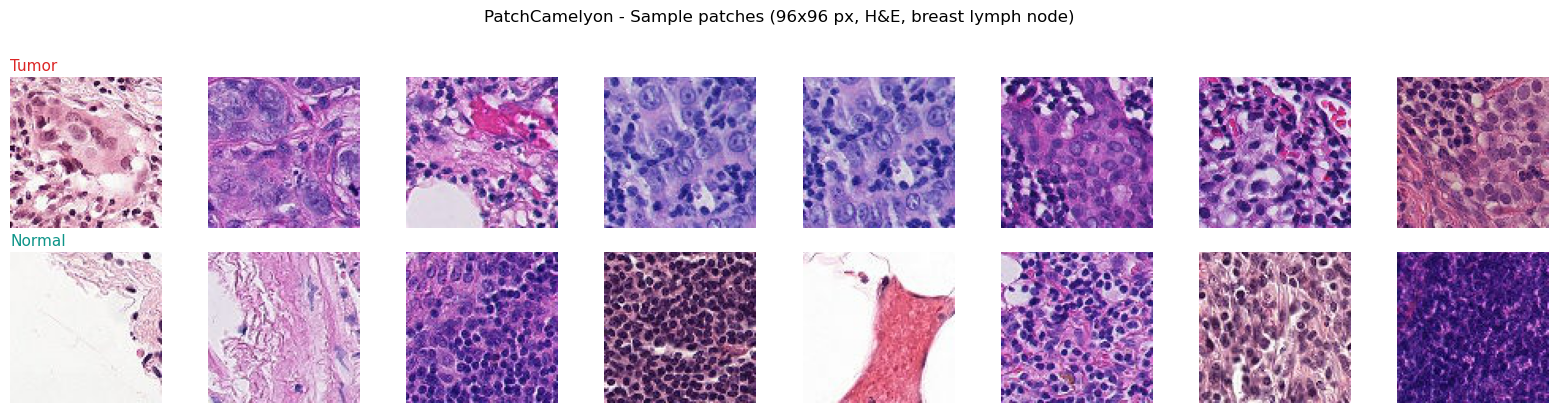

Saved: sample_patches.png


In [5]:
# Collect indices for 8 tumor and 8 normal patches
tumor_idx  = np.where(labels_all == 1)[0][:8]
normal_idx = np.where(labels_all == 0)[0][:8]

with h5py.File(X_FILE, 'r') as f:
    tumor_patches  = f['x'][tumor_idx]   # (8, 96, 96, 3)
    normal_patches = f['x'][normal_idx]  # (8, 96, 96, 3)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.patch.set_facecolor('white')

for i in range(8):
    axes[0, i].imshow(tumor_patches[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Tumor', fontsize=11, fontname='DejaVu Sans',
                              color='#DC2626', loc='left', pad=4)

    axes[1, i].imshow(normal_patches[i])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Normal', fontsize=11, fontname='DejaVu Sans',
                              color='#0D9488', loc='left', pad=4)

plt.suptitle('PatchCamelyon - Sample patches (96x96 px, H&E, breast lymph node)',
             fontsize=12, fontname='DejaVu Sans', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_patches.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_patches.png")

## Cell 6: Load Phikon-v2

We load two things from HuggingFace:

- `AutoImageProcessor`: handles resizing, normalization, and conversion to tensors. Phikon-v2 expects 224x224 input normalized with ImageNet mean/std.
- `AutoModel`: the ViT-Large model itself.

On first run, `from_pretrained` downloads the weights (~1.2 GB) and caches them under `C:\Users\m6sbhatt\.cache\huggingface\hub\`. On subsequent runs it loads from cache - fast.

We call `model.eval()` because we are doing inference only - this disables dropout and batch norm updates. We move the model to GPU with `.to(device)`.

In [6]:
MODEL_NAME = "owkin/phikon-v2"

print(f"Loading Phikon-v2 from cache (or downloading if first run) ...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model     = model.to(device)
model.eval()

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded on: {device}")
print(f"Parameters: {n_params / 1e6:.1f} M")
print(f"Expected embedding dimension: 1024")

Loading Phikon-v2 from cache (or downloading if first run) ...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Model loaded on: cuda
Parameters: 303.4 M
Expected embedding dimension: 1024


## Cell 7: Extract an embedding for a single patch

Before we scale up, let us understand exactly what the embedding extraction pipeline does for one patch. This is worth doing step by step:

1. The patch is a 96x96 numpy array of uint8 values (0-255 RGB)
2. `processor` resizes it to 224x224, normalizes pixel values, and returns a tensor
3. We pass it through the model with `torch.no_grad()` to skip gradient computation
4. The model returns a `BaseModelOutput`. We take `last_hidden_state[:, 0, :]` - this is the CLS token, a single 1024-dimensional vector that summarizes the whole patch

The CLS token is a standard ViT convention. Think of it as the model's answer to the question: "what is the overall character of this image patch?"

In [7]:
# Load one tumor patch
with h5py.File(X_FILE, 'r') as f:
    single_patch = f['x'][tumor_idx[0]]  # (96, 96, 3), uint8

print(f"Raw patch shape: {single_patch.shape}, dtype: {single_patch.dtype}")
print(f"Pixel value range: {single_patch.min()} - {single_patch.max()}")

# Step 1: convert to PIL (processor expects PIL or float tensor)
pil_patch = Image.fromarray(single_patch)
print(f"PIL size: {pil_patch.size}")  # width x height

# Step 2: processor - resize to 224x224, normalize
inputs = processor(images=pil_patch, return_tensors="pt").to(device)
print(f"Tensor shape after processor: {inputs['pixel_values'].shape}")
# (1, 3, 224, 224) - batch of 1, 3 channels, 224x224

# Step 3: forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Step 4: extract CLS token embedding
embedding = outputs.last_hidden_state[:, 0, :]  # (1, 1024)
embedding = embedding.cpu().numpy().squeeze()    # (1024,)

print(f"\nEmbedding shape: {embedding.shape}")
print(f"Embedding dtype: {embedding.dtype}")
print(f"First 8 values: {embedding[:8].round(4)}")
print(f"L2 norm: {np.linalg.norm(embedding):.4f}")

Raw patch shape: (96, 96, 3), dtype: uint8
Pixel value range: 0 - 255
PIL size: (96, 96)
Tensor shape after processor: torch.Size([1, 3, 224, 224])

Embedding shape: (1024,)
Embedding dtype: float32
First 8 values: [ 0.1041  0.4102 -0.1235 -0.2611 -0.2029  0.2096 -0.3374  0.3656]
L2 norm: 9.1901


## Cell 8: Sample 2000 patches - balanced tumor and normal

We will work with 2000 patches: 1000 tumor and 1000 normal. This is enough to get a meaningful UMAP visualization and runs through Phikon-v2 in a few minutes on GPU.

We randomly sample the indices rather than taking the first 1000 of each, to avoid any ordering artifacts in the dataset.

We load all 2000 patches into memory at once. At 96x96x3 uint8, 2000 patches is about 55 MB - no problem.

In [8]:
N_SAMPLE = 1000  # per class
rng = np.random.default_rng(seed=42)

tumor_pool  = np.where(labels_all == 1)[0]
normal_pool = np.where(labels_all == 0)[0]

tumor_sample  = rng.choice(tumor_pool,  size=N_SAMPLE, replace=False)
normal_sample = rng.choice(normal_pool, size=N_SAMPLE, replace=False)

# Combine and sort so we read h5 in index order (faster)
all_idx    = np.concatenate([tumor_sample, normal_sample])
all_labels = np.array([1] * N_SAMPLE + [0] * N_SAMPLE)

sort_order = np.argsort(all_idx)
all_idx    = all_idx[sort_order]
all_labels = all_labels[sort_order]

with h5py.File(X_FILE, 'r') as f:
    patches = f['x'][all_idx]  # (2000, 96, 96, 3)

print(f"Sampled {len(patches)} patches")
print(f"Tumor:  {all_labels.sum()}")
print(f"Normal: {(all_labels == 0).sum()}")
print(f"patches array shape: {patches.shape}, size in memory: {patches.nbytes / 1e6:.1f} MB")

Sampled 2000 patches
Tumor:  1000
Normal: 1000
patches array shape: (2000, 96, 96, 3), size in memory: 55.3 MB


## Cell 9: Extract embeddings for all 2000 patches

We process patches in batches of 32. Each batch goes through the processor and the model together, which is much more efficient than sending one patch at a time.

The progress bar shows estimated time remaining. On an NVIDIA RTX 4000 Ada this takes roughly 2-3 minutes.

**We save the embeddings and labels to disk immediately after extraction.** This is important: if your kernel restarts or you close VS Code, you can reload from these files and skip straight to the visualization cells without re-running Phikon-v2.

In [9]:
BATCH_SIZE = 32

all_embeddings = []

n_batches = int(np.ceil(len(patches) / BATCH_SIZE))

for i in tqdm(range(n_batches), desc="Extracting embeddings"):
    batch = patches[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]  # (B, 96, 96, 3)

    # Convert batch to list of PIL images
    pil_batch = [Image.fromarray(img) for img in batch]

    # Processor handles the whole batch at once
    inputs = processor(images=pil_batch, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token for each image in the batch: (B, 1024)
    batch_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    all_embeddings.append(batch_emb)

embeddings = np.vstack(all_embeddings)  # (2000, 1024)

# Save to disk
np.save(EMBED_FILE,  embeddings)
np.save(LABELS_FILE, all_labels)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Saved to:")
print(f"  {EMBED_FILE}")
print(f"  {LABELS_FILE}")

Extracting embeddings: 100%|██████████| 63/63 [00:29<00:00,  2.12it/s]

Embeddings shape: (2000, 1024)
Saved to:
  C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\pcam\embeddings_2000.npy
  C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\pcam\labels_2000.npy


## Cell 10: Reload embeddings from disk (run this if kernel restarted)

If you close VS Code and come back, or if the kernel restarts for any reason, run this cell to reload the saved embeddings. You can then run all remaining cells without re-running Phikon-v2.

Cells 1-2 (imports and paths) still need to be run first.

In [10]:
embeddings = np.load(EMBED_FILE)
all_labels = np.load(LABELS_FILE)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {all_labels.shape}")
print(f"Tumor: {all_labels.sum()}, Normal: {(all_labels == 0).sum()}")

Embeddings shape: (2000, 1024)
Labels shape: (2000,)
Tumor: 1000, Normal: 1000


## Cell 11: UMAP - colored by tumor/normal label

UMAP (Uniform Manifold Approximation and Projection) reduces the 1024-dimensional embeddings down to 2 dimensions for visualization. It tries to preserve the neighborhood structure of the high-dimensional space - points that are close in 1024 dimensions should end up close in 2D.

The key question: do the tumor and normal patches form separate clusters, even though the model was never shown any labels during feature extraction?

If the foundation model has learned a general representation of tissue appearance, the answer should be yes - tumor tissue looks different enough that it occupies a different region of embedding space.

`n_neighbors=30` controls how local vs global the structure is. `min_dist=0.1` controls how tightly points pack together in 2D. These are reasonable defaults for 2000 points.

In [11]:
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn",
                    "--break-system-packages", "-q"], check=True)
    import umap

print("Running UMAP on 2000 x 1024 embeddings ...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2,
                    metric='cosine', random_state=42, verbose=False)
umap_coords = reducer.fit_transform(embeddings)  # (2000, 2)
print(f"UMAP output shape: {umap_coords.shape}")

# Save UMAP coords so we don't have to recompute
umap_file = os.path.join(OUTPUT_DIR, "umap_coords_2000.npy")
np.save(umap_file, umap_coords)
print(f"Saved UMAP coords to: {umap_file}")

Running UMAP on 2000 x 1024 embeddings ...


c:\Users\m6sbhatt\AppData\Local\anaconda3\envs\torch-gpu-pathology\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (2000, 2)
Saved UMAP coords to: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\data\pcam\umap_coords_2000.npy


## Cell 12: Plot UMAP colored by label

Each dot is one 96x96 patch. Red = tumor, teal = normal. The model never saw these labels - all it produced was a 1024-dim vector per patch.

If the embedding is any good, you should see meaningful separation. The clusters do not have to be perfectly clean - the dataset has ambiguous patches where the central region is at the boundary of a lesion - but the broad structure should be clear.

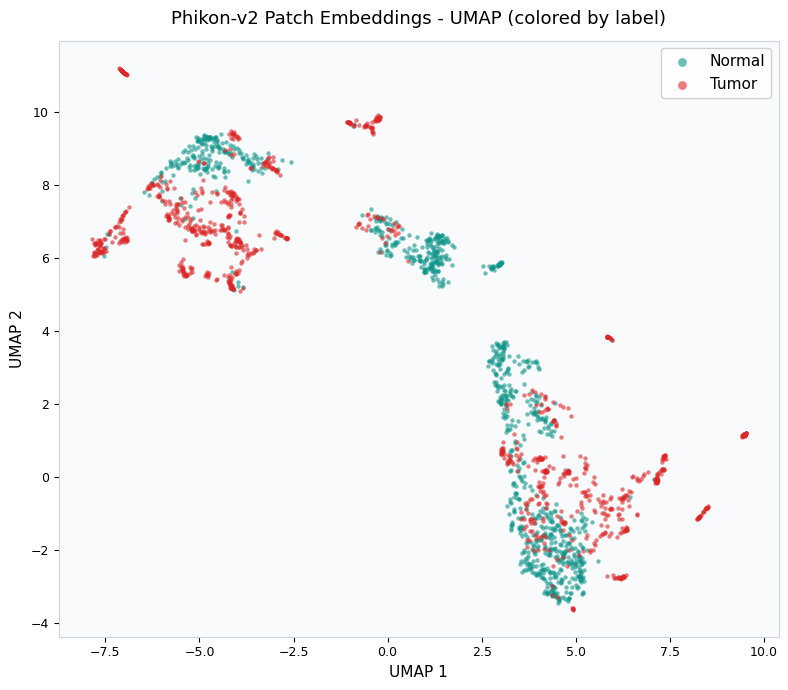

Saved: umap_by_label.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFC')

colors = {1: '#DC2626', 0: '#0D9488'}
labels_str = {1: 'Tumor', 0: 'Normal'}

for label_val in [0, 1]:
    mask = all_labels == label_val
    ax.scatter(
        umap_coords[mask, 0], umap_coords[mask, 1],
        c=colors[label_val], label=labels_str[label_val],
        s=10, alpha=0.6, linewidths=0
    )

ax.set_title('Phikon-v2 Patch Embeddings - UMAP (colored by label)',
             fontname='DejaVu Sans', fontsize=13, pad=12)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=11)
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=11)
ax.legend(fontsize=11, markerscale=2, framealpha=0.9)
ax.tick_params(labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#CBD5E1')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_by_label.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_by_label.png")

## Cell 13: UMAP colored by first PCA component

The label plot shows that tumor and normal separate. But what does the embedding space actually encode beyond that binary distinction?

To get a sense of the continuous structure, we project the embeddings onto the first principal component using PCA - this is the single direction in 1024-dimensional space that captures the most variance. We then color each point by its position along that axis.

What you typically see is that PC1 roughly aligns with the tumor-normal axis, but the gradient also captures sub-structure within each cluster - for example, varying nuclear density within the tumor region, or different stroma types within normal. This is the kind of biological signal the model has learned without explicit supervision.

The colormap goes from navy (low PC1) to teal to amber (high PC1) to make the gradient easy to read.

PC1 explained variance: 14.7%


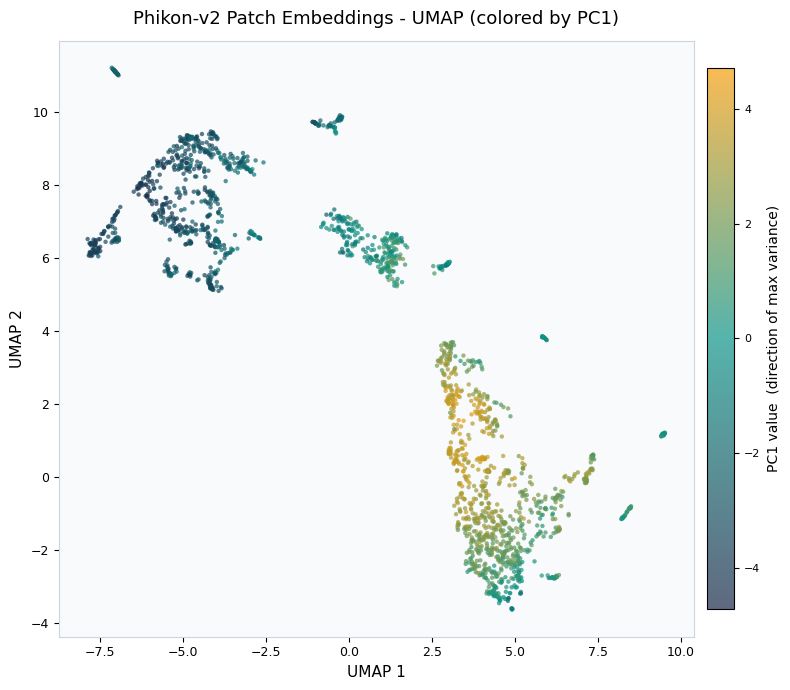

Saved: umap_by_pc1.png


In [13]:
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

# PCA - just the first component
pca = PCA(n_components=1)
pc1_values = pca.fit_transform(embeddings).squeeze()  # (2000,)
print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.1f}%")

# Custom colormap: navy -> teal -> amber
cmap_colors = ['#1B2A4A', '#0D9488', '#F59E0B']
custom_cmap = LinearSegmentedColormap.from_list('pathology', cmap_colors, N=256)

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8FAFC')

sc = ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    c=pc1_values, cmap=custom_cmap,
    s=10, alpha=0.7, linewidths=0
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('PC1 value  (direction of max variance)', fontname='DejaVu Sans', fontsize=10)
cbar.ax.tick_params(labelsize=8)

ax.set_title('Phikon-v2 Patch Embeddings - UMAP (colored by PC1)',
             fontname='DejaVu Sans', fontsize=13, pad=12)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=11)
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=11)
ax.tick_params(labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#CBD5E1')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_by_pc1.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_by_pc1.png")

## Cell 14: Side-by-side comparison of both UMAP plots

Putting both plots next to each other makes the comparison easier to follow in a video. The left plot shows the hard binary label; the right shows the continuous structure the model has encoded.

Notice that where the two clusters blend or overlap on the label plot, the PC1 plot often shows a gradient rather than a sharp boundary. Those are the ambiguous patches - tissue at the edge of a lesion, or patches where the central region is borderline. The embedding captures that uncertainty as a position in between the two clusters, not as a coin flip.

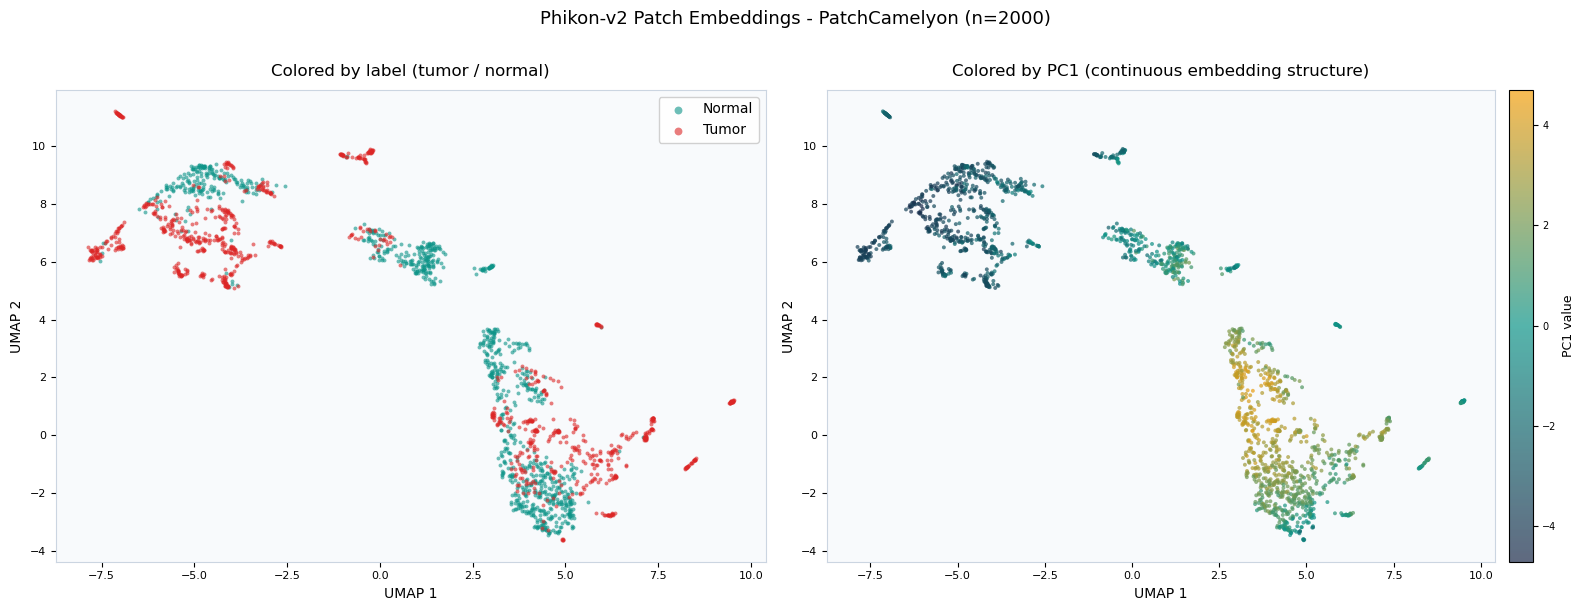

Saved: umap_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# --- Left: by label ---
ax = axes[0]
ax.set_facecolor('#F8FAFC')
for label_val in [0, 1]:
    mask = all_labels == label_val
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
               c=colors[label_val], label=labels_str[label_val],
               s=8, alpha=0.6, linewidths=0)
ax.set_title('Colored by label (tumor / normal)',
             fontname='DejaVu Sans', fontsize=12, pad=10)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=10)
ax.legend(fontsize=10, markerscale=2, framealpha=0.9)
ax.tick_params(labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#CBD5E1')

# --- Right: by PC1 ---
ax = axes[1]
ax.set_facecolor('#F8FAFC')
sc = ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
                c=pc1_values, cmap=custom_cmap,
                s=8, alpha=0.7, linewidths=0)
cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('PC1 value', fontname='DejaVu Sans', fontsize=9)
cbar.ax.tick_params(labelsize=7)
ax.set_title('Colored by PC1 (continuous embedding structure)',
             fontname='DejaVu Sans', fontsize=12, pad=10)
ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=10)
ax.tick_params(labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#CBD5E1')

plt.suptitle('Phikon-v2 Patch Embeddings - PatchCamelyon (n=2000)',
             fontname='DejaVu Sans', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_comparison.png")

## Cell 15: Cosine similarity between patches

UMAP gives us a global picture. Now let us look at something more concrete: how similar are specific patches to each other in embedding space?

We use cosine similarity - the angle between two embedding vectors. A value of 1.0 means the vectors point in exactly the same direction (maximally similar). A value close to 0 means they are nearly orthogonal (unrelated). In practice, for pathology patches from the same tissue type you expect similarities in the 0.7-0.95 range.

We take a small grid: 4 tumor patches and 4 normal patches, and compute all pairwise similarities. The resulting 8x8 heatmap should show a block structure: high similarity within tumor-tumor and normal-normal pairs, lower similarity across tumor-normal pairs.

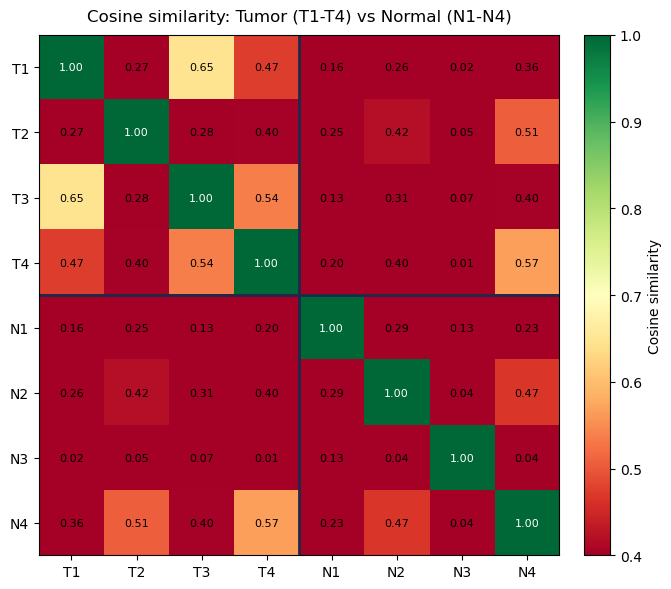

Saved: cosine_similarity_heatmap.png


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Pick 4 tumor and 4 normal patches from our sampled set
t_idx = np.where(all_labels == 1)[0][:4]
n_idx = np.where(all_labels == 0)[0][:4]
grid_idx = np.concatenate([t_idx, n_idx])  # 8 patches total

grid_emb    = embeddings[grid_idx]    # (8, 1024)
grid_labels = all_labels[grid_idx]    # (8,)
grid_patches = patches[grid_idx]      # (8, 96, 96, 3)

sim_matrix = cosine_similarity(grid_emb)  # (8, 8)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.4, vmax=1.0)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Cosine similarity')

tick_labels = [f"T{i+1}" for i in range(4)] + [f"N{i+1}" for i in range(4)]
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels(tick_labels, fontname='DejaVu Sans', fontsize=10)
ax.set_yticklabels(tick_labels, fontname='DejaVu Sans', fontsize=10)

# Annotate with values
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='black' if sim_matrix[i, j] < 0.85 else 'white')

# Draw divider between tumor and normal blocks
ax.axhline(3.5, color='#1B2A4A', linewidth=2)
ax.axvline(3.5, color='#1B2A4A', linewidth=2)

ax.set_title('Cosine similarity: Tumor (T1-T4) vs Normal (N1-N4)',
             fontname='DejaVu Sans', fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cosine_similarity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cosine_similarity_heatmap.png")

## Cell 16: Nearest-neighbor patch retrieval

The most practical use of embeddings is retrieval: given a query patch, find the most similar patches in a large collection.

This is exactly what a pathologist does mentally when they recognize a pattern - "I have seen something like this before, and it was grade 4." The embedding makes that process explicit and scalable.

We pick one query patch (a tumor patch), compute its cosine similarity to all 2000 patches, and display the top 5 nearest neighbors. We also show the 5 most dissimilar patches as a contrast.

A well-trained embedding should return nearest neighbors that look visually similar to the query - similar nuclear density, similar staining, similar architecture - even though the similarity is computed purely in the 1024-dimensional space.

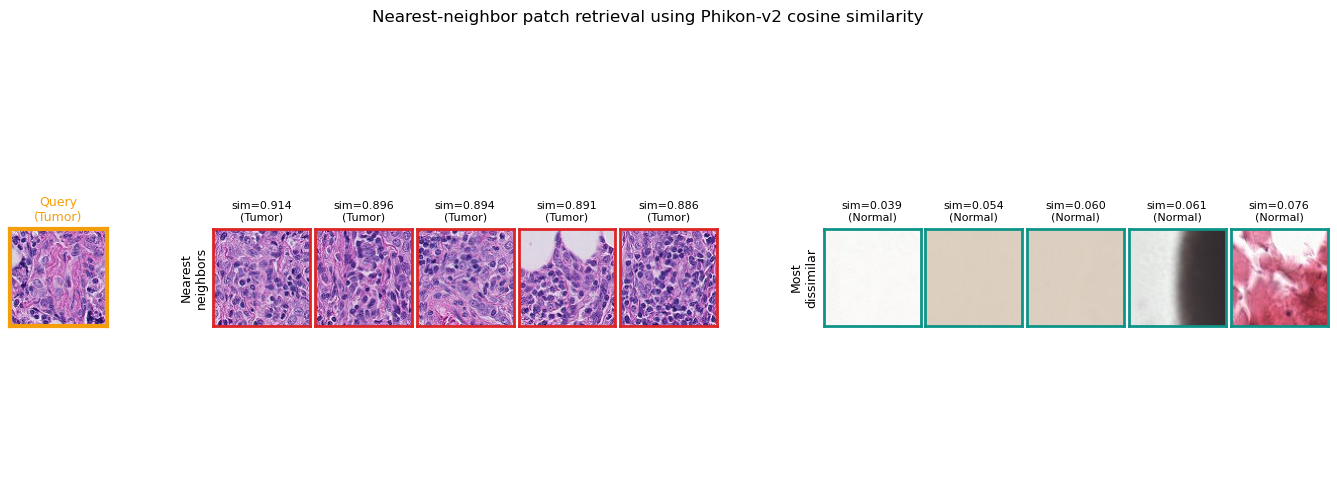

Saved: nearest_neighbors.png


In [16]:
# Query: one tumor patch from the middle of the tumor cluster in UMAP space
# We pick a patch with PC1 value near the median of the tumor class
tumor_mask  = all_labels == 1
tumor_pc1   = pc1_values[tumor_mask]
tumor_indices_in_sample = np.where(tumor_mask)[0]
median_tumor_idx = tumor_indices_in_sample[np.argmin(np.abs(tumor_pc1 - np.median(tumor_pc1)))]

query_emb   = embeddings[median_tumor_idx]
query_patch = patches[median_tumor_idx]
query_label = all_labels[median_tumor_idx]

# Cosine similarity to all 2000 patches
sims = cosine_similarity(query_emb.reshape(1, -1), embeddings).squeeze()

# Top 5 nearest (excluding the query itself)
sims[median_tumor_idx] = -1
top5_idx = np.argsort(sims)[-5:][::-1]
#bot5_idx = np.argsort(sims)[:5]
#sims[median_tumor_idx] = 1.0  # restore

# Get bottom 6 and drop the query index, then take first 5
bot6_idx = np.argsort(sims)[:6]
bot5_idx = bot6_idx[bot6_idx != median_tumor_idx][:5]

# Layout: query | spacer | 5 nearest | spacer | 5 dissimilar = 13 columns
fig = plt.figure(figsize=(17, 5))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 13, figure=fig, wspace=0.05)

def label_str(l):
    return 'Tumor' if l == 1 else 'Normal'

def border_color(l):
    return '#DC2626' if l == 1 else '#0D9488'

# Query patch - col 0
ax = fig.add_subplot(gs[0, 0])
ax.imshow(query_patch)
for spine in ax.spines.values():
    spine.set_edgecolor('#F59E0B')
    spine.set_linewidth(3)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Query\n({label_str(query_label)})', fontsize=9,
             fontname='DejaVu Sans', color='#F59E0B')

# Spacer - col 1
fig.add_subplot(gs[0, 1]).axis('off')

# Top 5 nearest - cols 2-6
for k, idx in enumerate(top5_idx):
    ax = fig.add_subplot(gs[0, 2 + k])
    ax.imshow(patches[idx])
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color(all_labels[idx]))
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'sim={sims[idx]:.3f}\n({label_str(all_labels[idx])})',
                 fontsize=8, fontname='DejaVu Sans')
    if k == 0:
        ax.set_ylabel('Nearest\nneighbors', fontsize=9, fontname='DejaVu Sans',
                      rotation=90, labelpad=4)

# Spacer - col 7
fig.add_subplot(gs[0, 7]).axis('off')

# Bottom 5 most dissimilar - cols 8-12
for k, idx in enumerate(bot5_idx):
    ax = fig.add_subplot(gs[0, 8 + k])
    ax.imshow(patches[idx])
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color(all_labels[idx]))
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'sim={sims[idx]:.3f}\n({label_str(all_labels[idx])})',
                 fontsize=8, fontname='DejaVu Sans')
    if k == 0:
        ax.set_ylabel('Most\ndissimilar', fontsize=9, fontname='DejaVu Sans',
                      rotation=90, labelpad=4)

fig.suptitle('Nearest-neighbor patch retrieval using Phikon-v2 cosine similarity',
             fontsize=12, fontname='DejaVu Sans', y=1.03)
plt.savefig(os.path.join(OUTPUT_DIR, 'nearest_neighbors.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nearest_neighbors.png")

## Summary

What we did in this notebook:

1. Loaded 96x96 H&E patches from the PatchCamelyon dataset using h5py
2. Ran 2000 patches through Phikon-v2 to get 1024-dimensional embeddings - no labels used during extraction
3. Reduced to 2D with UMAP and confirmed that tumor and normal patches separate in embedding space
4. Colored the UMAP by PC1 to show that the embedding encodes continuous biological variation beyond a simple binary split
5. Computed pairwise cosine similarity and showed that within-class similarity is higher than across-class
6. Used the embedding as a retrieval engine: given a query patch, return the most visually similar patches from the collection

**In Video 3**, we use these same embeddings to build a tissue region classifier on a real H&E slide image. We add a lightweight sklearn head on top of Phikon-v2 features and produce a spatial tissue map.

Code and notebooks: github.com/bnsreenu